# The sample generation interface, on real driving frames, against YOLOv8n

`T : x ↦ x′`: one fully specified operation: algorithm + resolved parameters + seed + model. One row per output; no judgement on it.

Runs on ten **comma10k** frames (MIT), fetched by `scripts/fetch_comma10k_sample.py`; YOLOv8n's weights download once into `~/.cache/kcai-data-sampling/weights/`. One line in the setup cell switches to **WoodScape** for licensees.

| | |
| :--- | :--- |
| procedural | `HorizontalFlip`, `CropResize`, `CutMix` (n-ary) |
| adversarial | `FGSM` against YOLOv8n |
| generative | not yet, see the last section |

## 0 · Setup

In [1]:
import json, os
from pathlib import Path

import numpy as np
%config InlineBackend.figure_format = 'jpeg'   # photographs: keeps the committed notebook small

from kcai_data_sampling import FGSM, CropResize, CutMix, DataSelection, HorizontalFlip, TransformationRunner
from kcai_data_sampling.datasets import comma10k, woodscape
from kcai_data_sampling.models import YoloTarget
from kcai_data_sampling.utils.io import load_image, save_outputs

from display import show, show_detections, rows_table   # presentation only, next to this notebook

# Every path written (in a selection, in rows.json) is relative to the repository root.
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".git").exists())
os.chdir(REPO)
print("working from the repository root:", REPO)

DATASET, DATA = comma10k, Path("examples/data/comma10k_sample")      # scripts/fetch_comma10k_sample.py
# DATASET, DATA = woodscape, Path("examples/data/woodscape_sample")   # Valeo's fisheye corpus, for licensees

SELECTIONS = Path("examples/notebooks/outputs/selections")            # what each campaign ran on
OUTPUTS = Path("examples/notebooks/outputs/transformed_samples")      # what it produced, with rows.json, git-ignored

working from the repository root: /home/lucasschott/TechLab/kcai-workspace


## 1 · The samples

A sample is data **and** its annotation. `Sample.y` carries the annotation as the dataset gives it; the interface never reads it. Drawing it is the reader's job.

10 samples, x = (3, 1208, 1928) float32

  mask     on 10/10 samples



  movable pixels per frame: 13% – 41%


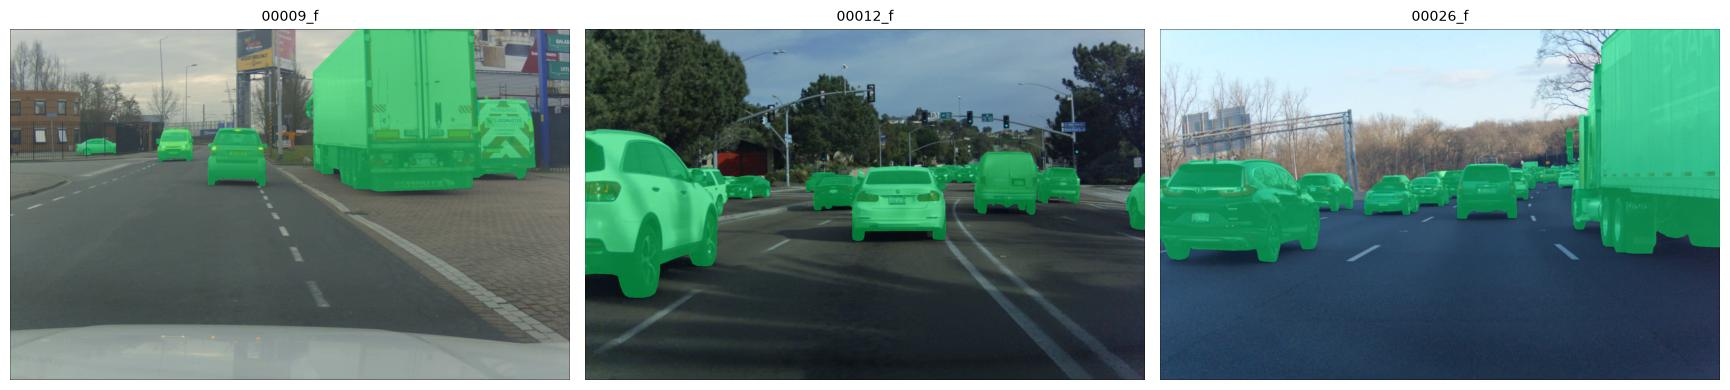

In [2]:
samples = DATASET.samples(DATA, limit=10)
DATASET.describe(samples)

show([(s.id, DATASET.overlay(s.x, s.y)) for s in samples[:3]])

## 2 · The data selection

The **dataset** is comma10k; the **data selection** is the ten frames this campaign covers; a **batch** is an execution detail chosen at run time. The selection is the authority on what a sample is (an `id` and a `source` per sample, and `sample_axes` for its shape) and is written to disk before anything runs, because every row will point at it by path.

In [3]:
selection = DataSelection(
    name=f"{DATASET.__name__.split('.')[-1]}-{len(samples)}",
    dataset=DATASET.__name__.split(".")[-1],      # the reader that assembles a sample from its source
    samples=samples,
    sample_axes=("channel", "height", "width"),
)
selection.save(SELECTIONS)                        # a row references this file; it has to exist first
runner = TransformationRunner(selection)

print(f"{len(selection)} samples, written to {selection.path}")
print("first entry:", json.dumps(selection.to_dict()["samples"][0], indent=2))

10 samples, written to examples/notebooks/outputs/selections/comma10k-10.json
first entry: {
  "id": "00009_f",
  "source": {
    "image": "examples/data/comma10k_sample/imgs/00009_f_20f59690c1da9379_2021-02-23--09-20-54_21_334.png",
    "mask": "examples/data/comma10k_sample/masks/00009_f_20f59690c1da9379_2021-02-23--09-20-54_21_334.png"
  }
}


The batch never reaches the row: one batch of ten, two of five, five of two or ten of one give the same rows in the same order.

In [4]:
flip = HorizontalFlip()
runs = {size: runner.run(flip, batch_size=size) for size in (10, 5, 2, 1)}

reference = runs[10]
for size, results in runs.items():
    same = all(np.array_equal(a, b) and ra.parent_id == rb.parent_id and ra.params == rb.params
               for (a, ra), (b, rb) in zip(results, reference))
    print(f"  batch_size={size:2} → {len(results)} rows, identical to one batch of 10: {same}")

  batch_size=10 → 10 rows, identical to one batch of 10: True
  batch_size= 5 → 10 rows, identical to one batch of 10: True
  batch_size= 2 → 10 rows, identical to one batch of 10: True
  batch_size= 1 → 10 rows, identical to one batch of 10: True


## 3 · What a transformation is

Algorithm, resolved parameters, seed, model, nothing left open, and that *is* the identity: no separate id on the row. The seed exists exactly when the algorithm draws; a deterministic one carries `seed = NULL` and refuses a seed.

In [5]:
a = CropResize({"fraction": 0.4})
b = CropResize({"fraction": 0.4})
c_ = CropResize({"fraction": 0.5})

identity = lambda t: (t.algorithm, json.dumps(t.params, sort_keys=True), t.seed)
same = lambda u, v: np.array_equal(u.transform(samples[0])[0], v.transform(samples[0])[0])
print(f"a vs b  same output {same(a, b)}   same identity {identity(a) == identity(b)}   seed on the row: {a.transform(samples[0])[1].seed}")
print(f"a vs c  same output {same(a, c_)}   same identity {identity(a) == identity(c_)}")

try:
    CropResize({"seed": 7, "fraction": 0.4})
except ValueError as e:
    print("\nrefused:", e)

a vs b  same output True   same identity True   seed on the row: None
a vs c  same output False   same identity False

refused: crop_resize draws no randomness: a seed means nothing here, and two seeds would name two transformations for one output


The family is the role of the model, derived from which of the two slots (`tool_model`, `target_model`) the algorithm needs. Exactly that slot must be filled; checked at construction.

In [6]:
target = YoloTarget()      # weights download once, into ~/.cache/kcai-data-sampling/weights/
print("weights:", target.weights, "\n")

for t in (HorizontalFlip(), FGSM({"target_model": target, "epsilon": 4 / 255})):
    tool, tgt = getattr(t.tool_model, "name", None), getattr(t.target_model, "name", None)
    print(f"{t.algorithm:16} model_role={str(t.model_role):8} tool_model={str(tool):8} target_model={str(tgt):8} → {t.family}")

for bad in ({"epsilon": 4 / 255}, {"tool_model": target, "epsilon": 4 / 255}):
    try:
        FGSM(bad)
    except ValueError as e:
        print("\nrefused:", e)

weights: /home/lucasschott/.cache/kcai-data-sampling/weights/yolov8n.pt 

horizontal_flip  model_role=None     tool_model=None     target_model=None     → procedural
fgsm             model_role=target   tool_model=None     target_model=yolov8n  → adversarial

refused: fgsm: model_role='target' but target_model=None, the family is the role of the model

refused: fgsm: model_role='target' but tool_model='yolov8n', the family is the role of the model


## 4 · Procedural

`CropResize` keeps a window and resamples it back to the original size, which keeps `x′` in the same space as `x` (section 7).

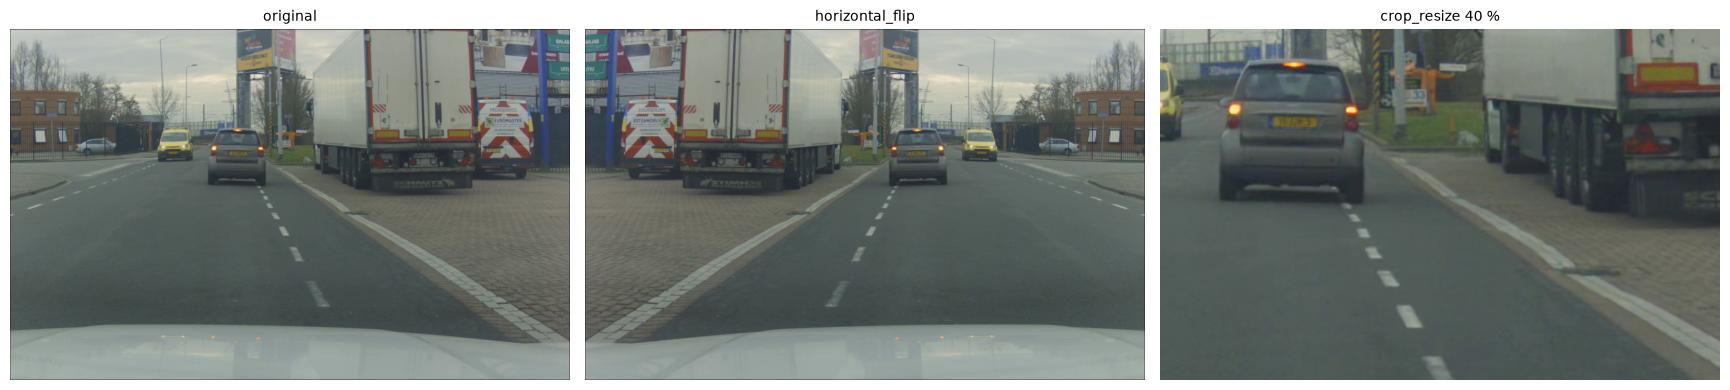

one row per output, every column


,data_selection_path,parent_id,algorithm,family,arity,reversible,params,seed,tool_model,target_model,sample_path
0,examples/notebooks/outputs/selections/comma10k-10.json,00009_f,horizontal_flip,procedural,unary,True,{},",",",",",",examples/notebooks/outputs/transformed_samples/comma10k-10__00009_f__horizontal_flip__6532a7__2723db.png
1,examples/notebooks/outputs/selections/comma10k-10.json,00009_f,crop_resize,procedural,unary,False,"{'fraction': 0.4, 'top': 300, 'left': 600}",",",",",",",examples/notebooks/outputs/transformed_samples/comma10k-10__00009_f__crop_resize__68034a__221706.png


In [7]:
zoom = CropResize({"fraction": 0.4, "top": 300, "left": 600})

sample = samples[0]
flipped, flip_row = runner.run(flip, [sample])[0]
zoomed,  zoom_row = runner.run(zoom, [sample])[0]

save_outputs(OUTPUTS, [(flipped, flip_row), (zoomed, zoom_row)])   # storage assigns sample_path

show([("original", sample.x), ("horizontal_flip", flipped), ("crop_resize 40 %", zoomed)])
rows_table([flip_row, zoom_row], "one row per output, every column")

## 5 · N-ary: CutMix

`(x₁, x₂) ↦ x′`: the right half of the second parent pasted onto the first. The algorithm chooses its parents over the whole selection (each sample with the next); the row names both parents, and `δ` is undefined since there is no single source.

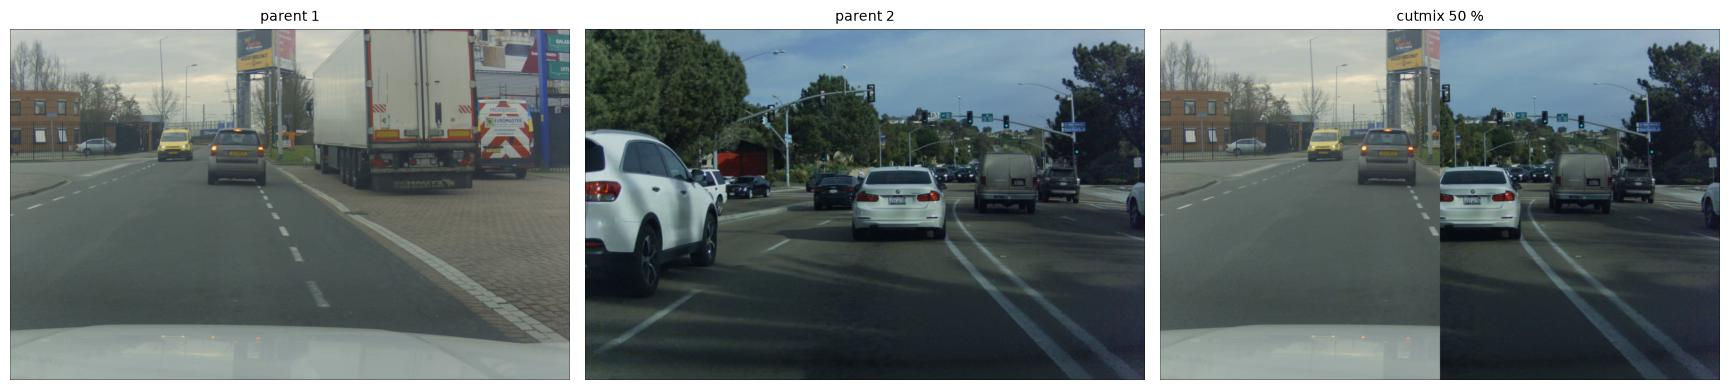

the n-ary row: two parents, arity = n-ary


,data_selection_path,parent_id,algorithm,family,arity,reversible,params,seed,tool_model,target_model,sample_path
0,examples/notebooks/outputs/selections/comma10k-10.json,"00009_f,00012_f",cutmix,procedural,n-ary,False,{},",",",",",","examples/notebooks/outputs/transformed_samples/comma10k-10__00009_f,00012_f__cutmix__6532a7__89ee78.png"


In [8]:
mixed, mix_row = runner.run(CutMix(), samples[:2])[0]
save_outputs(OUTPUTS, [(mixed, mix_row)])

show([("parent 1", samples[0].x), ("parent 2", samples[1].x), ("cutmix 50 %", mixed)])
rows_table([mix_row], "the n-ary row: two parents, arity = n-ary")

## 6 · Adversarial, FGSM against YOLOv8n

The output is computed *against* a **target** model. The interface asks it for one thing, a gradient with respect to the input; `YoloTarget` returns it at the original resolution.

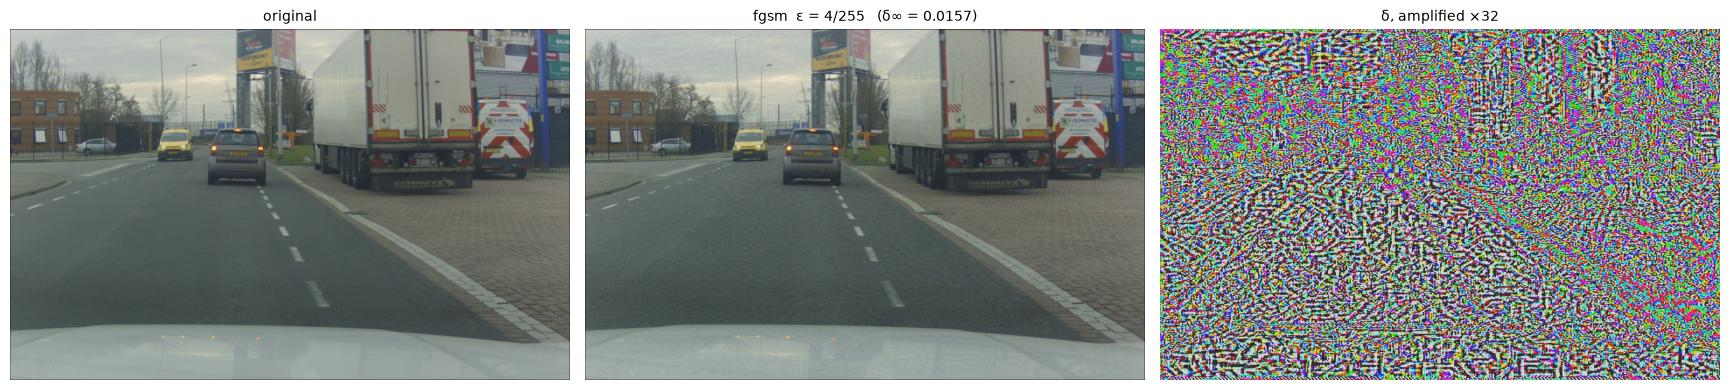

the adversarial row, target_model = yolov8n, reversible = True


,data_selection_path,parent_id,algorithm,family,arity,reversible,params,seed,tool_model,target_model,sample_path
0,examples/notebooks/outputs/selections/comma10k-10.json,00009_f,fgsm,adversarial,unary,False,{'epsilon': 0.01568627450980392},",",",",yolov8n,examples/notebooks/outputs/transformed_samples/comma10k-10__00009_f__fgsm__a849c8__d860e5.png


In [9]:
EPS = 4 / 255
attack = FGSM({"target_model": target, "epsilon": EPS})

attacked, attack_row = runner.run(attack, [sample])[0]
save_outputs(OUTPUTS, [(attacked, attack_row)])
delta = attacked - sample.x

show([("original", sample.x),
      (f"fgsm  ε = 4/255   (δ∞ = {np.abs(delta).max():.4f})", attacked),
      ("δ, amplified ×32", 0.5 + delta / (2 * EPS))])
rows_table([attack_row], "the adversarial row, target_model = yolov8n, reversible = True")

`reversible = True` is a declaration about the shape of the map, it stops holding where the range clip destroys values. Whether this output is an augmentation or a corruption is not on the row: a downstream judge decides, against a task the interface does not record, with this flag as its one free fact.

## 7 · `x′` lives in the same space as `x`

Checked on every output; it is what keeps `δ = x′ − x` defined. Enlarging (super-resolution, outpainting) is out of scope.

In [10]:
from kcai_data_sampling.api.unary import UnaryTransformation

class ShrinksTheSample(UnaryTransformation):
    algorithm = "shrinks"
    def apply(self, x, rng):
        return x[..., :400, :400]

try:
    runner.run(ShrinksTheSample(), [sample])
except ValueError as e:
    print("refused:", e)

refused: shrinks changed the sample space: (3, 1208, 1928) → (3, 400, 400). A unary transformation preserves it, so that δ stays defined.


## 8 · Did the attack work?

Not the interface's question, the model under evaluation is never called during generation. This is a **downstream module**, shown only to mark the boundary. FGSM takes one signed step of `4/255` against the most confident response: the top confidence is what it lowers; counts are a by-product.

In [11]:
from ultralytics import YOLO

detector = YOLO(str(target.weights))
VEHICLES = {"car", "truck", "bus", "motorcycle"}

def as_uint8_bgr(x):
    return (np.clip(x, 0, 1).transpose(1, 2, 0)[..., ::-1] * 255).round().astype("uint8")

def detect(x, conf=0.25):
    r = detector(as_uint8_bgr(x), conf=conf, verbose=False)[0]
    return [{"name": r.names[int(c)], "conf": float(p), "box": [float(v) for v in xyxy]}
            for c, p, xyxy in zip(r.boxes.cls, r.boxes.conf, r.boxes.xyxy)]

def summary(d):
    return (sum(e["name"] in VEHICLES for e in d), max((e["conf"] for e in d), default=0.0))

results = runner.run(attack, samples[:5])
print(f"{'':10} {'vehicles':>12} {'top conf':>14}     ground truth")
for parent, (x_prime, _) in zip(samples[:5], results):
    v0, c0 = summary(detect(parent.x)); v1, c1 = summary(detect(x_prime))
    print(f"{parent.id:10} {v0:5} → {v1:<5} {c0:7.2f} → {c1:.2f}     {DATASET.ground_truth(parent)}")

               vehicles       top conf     ground truth


00009_f        5 → 5        0.70 → 0.81     movable 17%


00012_f       11 → 11       0.89 → 0.86     movable 16%


00026_f       11 → 11       0.95 → 0.89     movable 26%


00035_f        3 → 3        0.82 → 0.57     movable 20%


00040_f        4 → 4        0.93 → 0.87     movable 41%


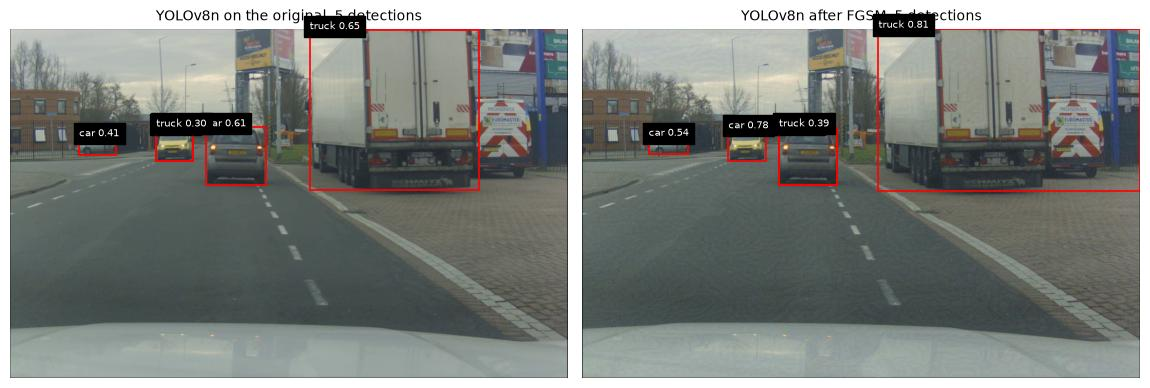

In [12]:
show_detections([("YOLOv8n on the original", sample.x, detect(sample.x)),
                 ("YOLOv8n after FGSM", attacked, detect(attacked))], vehicles=VEHICLES)

## 9 · What one row carries, and what it does not

Subtraction, not accumulation: a field is on the row only if it can be neither retrieved through a reference nor recomputed afterwards. Every row produced on the first frame, every column:

In [13]:
rows_table([flip_row, zoom_row, mix_row, attack_row], "four transformations, one row each, no measurement of any kind")

four transformations, one row each, no measurement of any kind


,data_selection_path,parent_id,algorithm,family,arity,reversible,params,seed,tool_model,target_model,sample_path
0,examples/notebooks/outputs/selections/comma10k-10.json,00009_f,horizontal_flip,procedural,unary,True,{},",",",",",",examples/notebooks/outputs/transformed_samples/comma10k-10__00009_f__horizontal_flip__6532a7__2723db.png
1,examples/notebooks/outputs/selections/comma10k-10.json,00009_f,crop_resize,procedural,unary,False,"{'fraction': 0.4, 'top': 300, 'left': 600}",",",",",",",examples/notebooks/outputs/transformed_samples/comma10k-10__00009_f__crop_resize__68034a__221706.png
2,examples/notebooks/outputs/selections/comma10k-10.json,"00009_f,00012_f",cutmix,procedural,n-ary,False,{},",",",",",","examples/notebooks/outputs/transformed_samples/comma10k-10__00009_f,00012_f__cutmix__6532a7__89ee78.png"
3,examples/notebooks/outputs/selections/comma10k-10.json,00009_f,fgsm,adversarial,unary,False,{'epsilon': 0.01568627450980392},",",",",yolov8n,examples/notebooks/outputs/transformed_samples/comma10k-10__00009_f__fgsm__a849c8__d860e5.png


No `δ`, no PSNR: a **downstream module** computes them from the row, since `params` and `seed` replay the run. The magnitude says nothing about what was lost, the flip scores as destroyed and is reversible, the crop scores the same and is not.

In [14]:
def measure(parent, x_prime):
    d = x_prime - parent.x
    mse = float(np.mean(d ** 2))
    return {"delta_linf": float(np.abs(d).max()), "delta_l2": float(np.sqrt((d ** 2).sum())),
            "psnr_db": float("inf") if mse == 0 else float(10 * np.log10(1 / mse))}

print(f"{'':16} {'δ∞':>8} {'δ2':>9} {'PSNR':>9}   reversible")
for x_prime, row in ((flipped, flip_row), (zoomed, zoom_row), (attacked, attack_row)):
    m = measure(sample, x_prime)
    print(f"{row.algorithm:16} {m['delta_linf']:8.4f} {m['delta_l2']:9.1f} {m['psnr_db']:8.1f}   {row.reversible}")

                       δ∞        δ2      PSNR   reversible
horizontal_flip    0.8196     383.6     16.8   True
crop_resize        0.9490     497.4     14.5   False
fgsm               0.0157      33.8     37.9   False


## 10 · What was written, and how a row leads back

Two directories under one root: the selection, and `x′` with `rows.json`: a ledger of every output in the directory. A file name carries the selection, the parent, the algorithm, a hash of `params` and `seed`, and a hash of the content as written: two settings on one parent are two files, two different outputs of one identity are two files and two rows, a bit-identical re-run replaces its own row.

In [15]:
for directory in (SELECTIONS, OUTPUTS):
    print(directory, ":")
    for p in sorted(directory.iterdir()):
        print("   ", p.name)
print()
print(json.dumps({k: (v if k != "samples" else v[:2] + ["…"]) for k, v in json.loads(Path(selection.path).read_text()).items()}, indent=2))

examples/notebooks/outputs/selections :
    comma10k-10.json
examples/notebooks/outputs/transformed_samples :
    comma10k-10__00009_f,00012_f__cutmix__6532a7__89ee78.png
    comma10k-10__00009_f__crop_resize__68034a__221706.png
    comma10k-10__00009_f__fgsm__a849c8__d860e5.png
    comma10k-10__00009_f__horizontal_flip__6532a7__2723db.png
    rows.json

{
  "name": "comma10k-10",
  "dataset": "comma10k",
  "sample_axes": [
    "channel",
    "height",
    "width"
  ],
  "samples": [
    {
      "id": "00009_f",
      "source": {
        "image": "examples/data/comma10k_sample/imgs/00009_f_20f59690c1da9379_2021-02-23--09-20-54_21_334.png",
        "mask": "examples/data/comma10k_sample/masks/00009_f_20f59690c1da9379_2021-02-23--09-20-54_21_334.png"
      }
    },
    {
      "id": "00012_f",
      "source": {
        "image": "examples/data/comma10k_sample/imgs/00012_f_a1fc603d9a8ddfc4_2021-02-14--14-05-48_71_125.png",
        "mask": "examples/data/comma10k_sample/masks/00012_f_a1fc60

From one row and nothing else in memory: `data_selection_path` → the selection, `parent_id` → its source, the reader the selection names → the parent.

In [16]:
import importlib

rows = json.loads((OUTPUTS / "rows.json").read_text())
row = next(r for r in rows if r["algorithm"] == "horizontal_flip")

written = json.loads(Path(row["data_selection_path"]).read_text())
entry = next(s for s in written["samples"] if s["id"] == row["parent_id"])
reader = importlib.import_module(f"kcai_data_sampling.datasets.{written['dataset']}")
parent = reader.load_sample(entry["id"], entry["source"])

x_prime = load_image(row["sample_path"])
print(f"{len(rows)} rows in the ledger; parent {row['parent_id']!r} assembled from {list(entry['source'])} by {written['dataset']!r}")
print(f"undo the flip, compare to the parent: max |Δ| = {np.abs(x_prime[..., ::-1] - parent.x).max():.4f}   |   annotation: {DATASET.ground_truth(parent)}")

4 rows in the ledger; parent '00009_f' assembled from ['image', 'mask'] by 'comma10k'
undo the flip, compare to the parent: max |Δ| = 0.0000   |   annotation: movable 17%


## 11 · Still open

- **The generative family**: needs a tool model with a real provenance; none chosen yet (CycleGAN weights gone, SD-Turbo too slow on CPU; a downsample-then-restore pair on a published super-resolution model is the next candidate). No toy will stand in.
- **OmniDet**, Valeo's detector trained on WoodScape; swapping it in touches the model adapter only.
- **The annotation**: out of scope: the interface never reads, moves or copies `y`, and the row says nothing about it.
- **Who judges the regime**: a downstream module, against a task it brings itself, with `reversible` on the row as its one free fact. The interface records no task.